# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証


## スコア分布

### 目的

分位分析や IC は順位に基づくため、スコアの分布形状が結果の解釈に直結する。`01_coverage.ipynb` に続き、

1. 全期間の分布（値域、離散性、ゼロへの集中）
2. 時系列での分布の推移（水準のトレンド、同順位の程度）
3. スコア帯ごとの銘柄数とサイズ（時価総額との関係）

を見て、後続の分位の切り方とサイズ効果の切り分け方針を決める。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import pandas as pd

from alphaeval import InputStore

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

# ---- パラメータ（別のファクターを検証する場合はここを変える）
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
BENCHMARK = "msci_india"
START, END = None, None  # None なら全期間

store = InputStore(INPUT_ROOT)


### 1. データ読み込み

`01_coverage.ipynb` と同じく、スコアが存在する期間に絞る。

In [2]:

univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
score = store.alpha(SCORE, START, END)

score_dates = score.index[score.notna().any(axis=1)]
period = slice(score_dates.min(), score_dates.max())
univ_p, bm_p, score_p = univ.loc[period], bm.loc[period], score.loc[period]
print(f"評価期間: {period.start.date()} 〜 {period.stop.date()}  ({len(univ_p)} か月)")
print(f"universe {univ_p.shape}, score {score_p.shape}")


評価期間: 2007-01-31 〜 2026-07-31  (235 か月)
universe (235, 1063), score (235, 700)


### 2. スコア分布（全期間）

ユニバース構成銘柄に付いたスコアの分布を確認する。分位分析は順位に基づくため、

- 値が離散的（整数）で **同順位（tie）が多い** と、分位の境界が恣意的になる
- ゼロなど特定の値に集中していると、その値の銘柄群が 1 つの分位に収まらず複数分位にまたがる

といった問題が起きる。RRI は 0〜100 の整数スコアで「高いほどレピュテーションリスクが高い」ので、
リターン予測の観点では低い方が良い（`higher_is_better=False`）ことも後続ステップで意識する。

観測数（日付 × 銘柄）: 59,930
整数のみ: True
値域: 0 〜 69
ゼロの割合: 54.2%


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
rri,59930.0,8.37,10.85,0.0,0.0,0.0,0.0,18.0,24.0,26.0,39.0,69.0


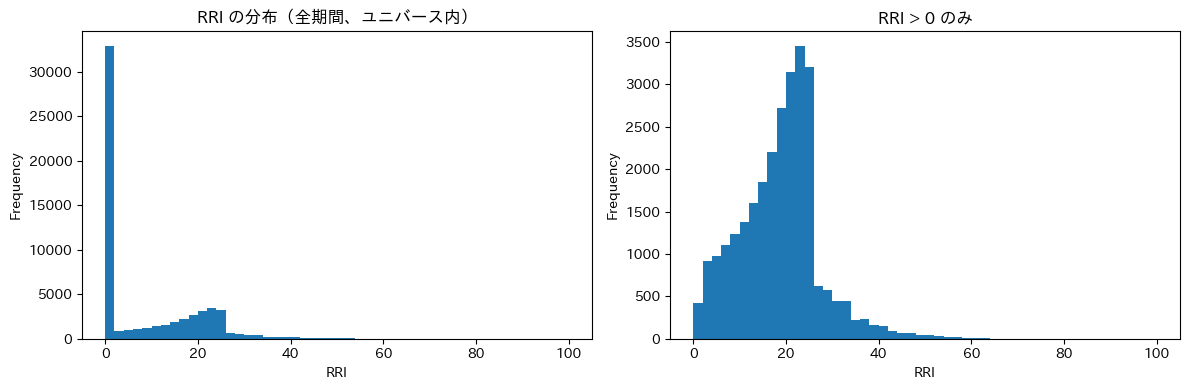

In [3]:
score_u = score_p.where(univ_p.notna())  # ユニバース内のみ
vals = score_u.stack().rename("rri")

print(f"観測数（日付 × 銘柄）: {len(vals):,}")
print(f"整数のみ: {bool((vals == vals.round()).all())}")
print(f"値域: {vals.min():.0f} 〜 {vals.max():.0f}")
print(f"ゼロの割合: {(vals == 0).mean():.1%}")
display(vals.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(2).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vals.plot.hist(bins=range(0, 102, 2), ax=axes[0])
axes[0].set_title("RRI の分布（全期間、ユニバース内）")
axes[0].set_xlabel("RRI")
vals[vals > 0].plot.hist(bins=range(0, 102, 2), ax=axes[1])
axes[1].set_title("RRI > 0 のみ")
axes[1].set_xlabel("RRI")
plt.tight_layout()
plt.show()


### 3. スコア分布（時系列）

月ごとの分位点（10 / 25 / 50 / 75 / 90 パーセンタイル）と平均、ゼロ比率、同順位の程度を追う。
同順位の程度は「ユニークな値の数 ÷ スコアあり銘柄数」で測る（1 に近いほど tie が少ない）。

,p10,p25,p50,p75,p90,mean,zero_share,unique_ratio
2007,0.0,0.0,0.000,0.000,15.892,2.995,0.854,0.116
2008,0.0,0.0,0.000,0.250,20.942,4.231,0.779,0.109
2009,0.0,0.0,0.000,3.000,19.067,4.301,0.735,0.116
2010,0.0,0.0,0.000,1.083,19.108,4.051,0.749,0.106
2011,0.0,0.0,0.000,6.792,22.042,5.392,0.715,0.114
2012,0.0,0.0,0.000,19.208,24.333,8.497,0.583,0.131
2013,0.0,0.0,1.417,18.500,23.750,8.873,0.504,0.160
2014,0.0,0.0,1.917,19.896,24.775,10.029,0.493,0.194
2015,0.0,0.0,0.000,17.812,23.100,8.328,0.523,0.153
2016,0.0,0.0,0.000,16.083,21.825,7.597,0.535,0.125


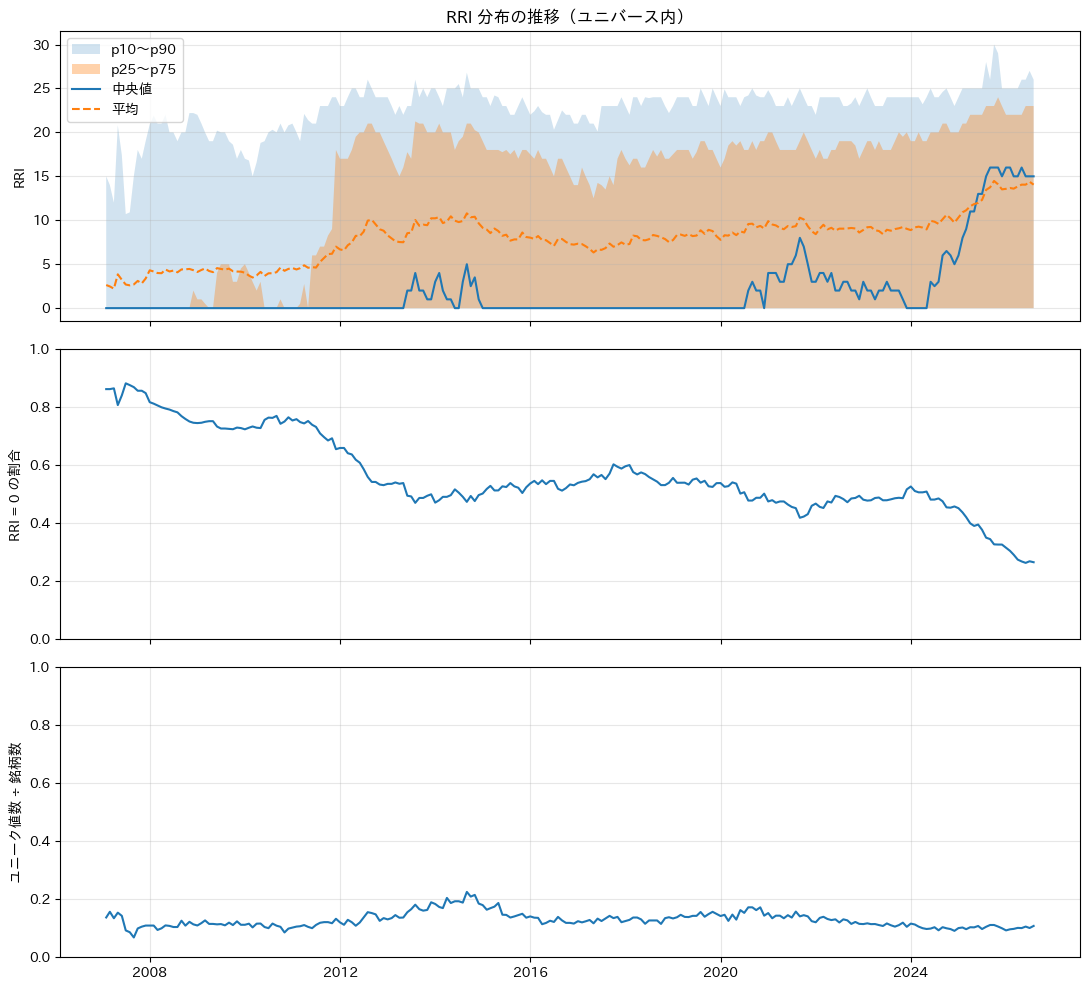

In [4]:
pct = score_u.quantile([0.1, 0.25, 0.5, 0.75, 0.9], axis=1).T
pct.columns = [f"p{int(q * 100)}" for q in pct.columns]
dist_ts = pct.assign(
    mean=score_u.mean(axis=1),
    zero_share=(score_u == 0).sum(axis=1) / score_u.notna().sum(axis=1),
    unique_ratio=score_u.nunique(axis=1) / score_u.notna().sum(axis=1),
)
display(dist_ts.groupby(dist_ts.index.year).mean().round(3))

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
axes[0].fill_between(pct.index, pct["p10"], pct["p90"], alpha=0.2, label="p10〜p90")
axes[0].fill_between(pct.index, pct["p25"], pct["p75"], alpha=0.35, label="p25〜p75")
axes[0].plot(pct.index, pct["p50"], label="中央値")
axes[0].plot(dist_ts.index, dist_ts["mean"], linestyle="--", label="平均")
axes[0].set_ylabel("RRI")
axes[0].set_title("RRI 分布の推移（ユニバース内）")
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)
# 下段も matplotlib で描く（pandas の .plot() を混ぜると x 軸の単位が変わり上段が消える）
axes[1].plot(dist_ts.index, dist_ts["zero_share"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("RRI = 0 の割合")
axes[1].grid(alpha=0.3)
axes[2].plot(dist_ts.index, dist_ts["unique_ratio"])
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("ユニーク値数 ÷ 銘柄数")
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 4. スコア帯ごとのサイズ

RepRisk 公式の区分（0–24 低、25–49 中、50–59 高、60–74 非常に高、75–100 極めて高）にゼロを別枠で加え、
各帯に入る銘柄数と、その銘柄群のサイズを確認する。サイズは 2 つの見方で測る。

- **時価総額シェア**: 帯に属する銘柄のユニバースウェイト合計（`univ/` のウェイトは浮動株調整後時価総額に比例）
- **相対サイズ**: 帯内の 1 銘柄あたり平均ウェイト ÷ ユニバース全体の 1 銘柄あたり平均ウェイト（1 を超えれば平均より大型）

高スコア帯（= レピュテーションリスク大）が大型株に偏っているかどうかは、分位分析でサイズ効果と切り分ける際に重要になる。

In [5]:
BANDS = [(-0.5, 0.5, "0"), (0.5, 24.5, "1–24"), (24.5, 49.5, "25–49"), (49.5, 59.5, "50–59"), (59.5, 74.5, "60–74"), (74.5, 100.5, "75–100")]
labels = [b[2] for b in BANDS]
band = pd.cut(score_u.stack(), bins=[b[0] for b in BANDS] + [BANDS[-1][1]], labels=labels)
band = band.unstack().reindex(index=score_u.index, columns=score_u.columns)
w_u = univ_p.div(univ_p.sum(axis=1), axis=0)  # 各日のウェイトを合計 1 に正規化
n_univ = univ_p.notna().sum(axis=1)

count_ts = pd.DataFrame({lab: (band == lab).sum(axis=1) for lab in labels})
cap_ts = pd.DataFrame({lab: w_u.where(band == lab).sum(axis=1) for lab in labels})
rel_size_ts = (cap_ts / count_ts.where(count_ts > 0)).mul(n_univ, axis=0)  # (帯の平均ウェイト) / (1/N)

summary_band = pd.DataFrame(
    {
        "平均銘柄数": count_ts.mean(),
        "銘柄数シェア": (count_ts.div(count_ts.sum(axis=1), axis=0)).mean(),
        "時価総額シェア": cap_ts.mean(),
        "相対サイズ（平均）": rel_size_ts.mean(),
        "相対サイズ（中央値）": rel_size_ts.median(),
    }
).round(3)
display(summary_band)


,平均銘柄数,銘柄数シェア,時価総額シェア,相対サイズ（平均）,相対サイズ（中央値）
0,138.196,0.566,0.255,0.585,0.555
1–24,97.366,0.363,0.522,2.090,2.099
25–49,18.860,0.069,0.143,2.945,2.724
50–59,0.511,0.002,0.004,2.898,2.170
60–74,0.089,0.000,0.000,1.632,1.521
75–100,0.000,0.000,0.000,NaN,NaN


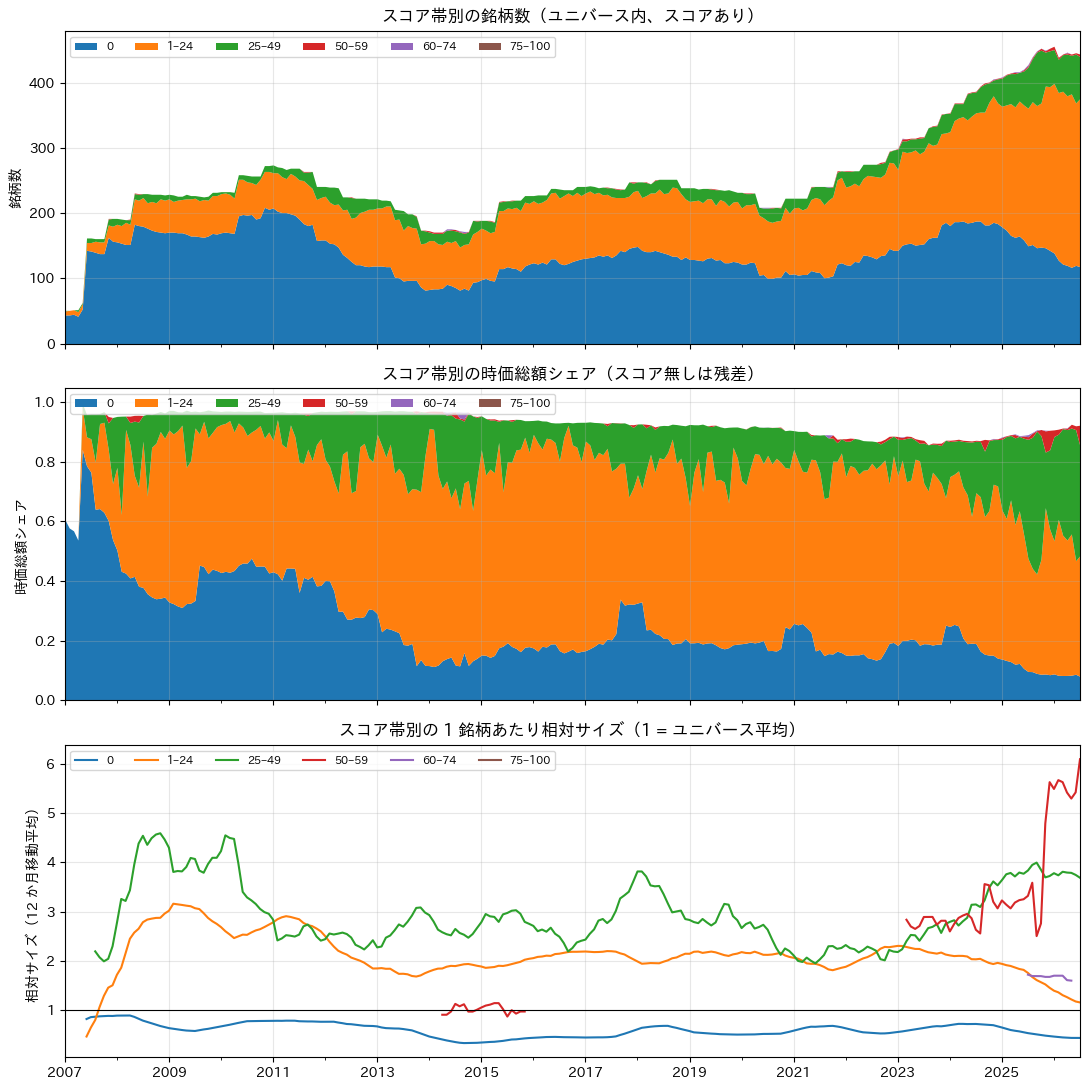

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=True)
count_ts.plot.area(ax=axes[0], linewidth=0)
axes[0].set_ylabel("銘柄数")
axes[0].set_title("スコア帯別の銘柄数（ユニバース内、スコアあり）")
axes[0].legend(loc="upper left", ncol=6, fontsize=8)
axes[0].grid(alpha=0.3)
cap_ts.plot.area(ax=axes[1], linewidth=0)
axes[1].set_ylabel("時価総額シェア")
axes[1].set_title("スコア帯別の時価総額シェア（スコア無しは残差）")
axes[1].legend(loc="upper left", ncol=6, fontsize=8)
axes[1].grid(alpha=0.3)
rel_size_ts.rolling(12, min_periods=6).mean().plot(ax=axes[2])
axes[2].axhline(1.0, color="k", linewidth=0.8)
axes[2].set_ylabel("相対サイズ（12 か月移動平均）")
axes[2].set_title("スコア帯別の 1 銘柄あたり相対サイズ（1 = ユニバース平均）")
axes[2].legend(loc="upper left", ncol=6, fontsize=8)
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()


年別に帯ごとの平均銘柄数を確認する。

In [7]:
display(count_ts.groupby(count_ts.index.year).mean().round(1))


,0,1–24,25–49,50–59,60–74,75–100
2007,104.1,12.9,4.6,0.1,0.0,0.0
2008,168.5,39.1,8.8,0.2,0.0,0.0
2009,167.4,54.4,5.9,0.0,0.0,0.0
2010,189.0,55.7,7.3,0.0,0.0,0.0
2011,188.8,59.5,15.2,0.2,0.0,0.0
2012,133.9,73.0,22.0,0.1,0.0,0.0
2013,102.8,83.6,16.7,0.2,0.0,0.0
2014,86.7,70.3,16.9,1.2,0.5,0.0
2015,110.2,86.6,13.2,0.4,0.0,0.0
2016,125.3,99.8,9.3,0.0,0.0,0.0


### 5. 所見

**スコア分布**

- RRI は 0〜100 の整数だが、本ユニバースの実際の値域は 0〜69。**観測の 54% がゼロ**で、中央値も 0。
  75 パーセンタイルが 18、90 パーセンタイルが 24 と、非ゼロの値も 1〜24（「低」区分）に集中している。
- 同順位が非常に多い。ユニーク値数 ÷ 銘柄数は年平均 0.10〜0.19（250 銘柄に対し値の種類は 30〜40）。
- 時系列では、ゼロ比率が 2007 年の 85% から低下を続け 2026 年に 28%、中央値も 2025 年以降はじめて 10 を超えた。
  RepRisk の報道カバレッジ拡大（インド企業の報道量増加）を反映しており、**スコア水準は時点間で比較できない**。
  クロスセクションの順位で扱うのが前提になる。

**スコア帯のサイズ**

- 帯別の平均銘柄数はゼロが 138、1–24 が 97、25–49 が 19。50 以上は月あたり 1 銘柄未満で、
  RepRisk の「高」以上の区分はこのユニバースではほぼ空。実質的な情報は「ゼロ / 低 / 中」の 3 区分に近い。
- サイズとの関係が明確。相対サイズ（1 = ユニバース平均）は、ゼロ帯 0.56、1–24 帯 2.1、25–49 帯 2.9。
  時価総額シェアで見るとゼロ帯は銘柄数の 57% を占めるが時価総額では 26%、25–49 帯は銘柄数 7% で時価総額 14%。
  **RRI が高い銘柄ほど大型**で、これは報道量が企業規模に比例することによる構造的なもの。

**後続ステップへの含意**

1. **順位付けと同順位**: ゼロが半数を占めるため、5 分位に切ると Q3〜Q5（RRI 低 = 良い側）がすべてゼロ銘柄で
   同順位になり、分位間の区別ができない。`alphaeval.rank_percentile` は平均順位（`method="average"`）を使うので
   ゼロ銘柄は全員同じパーセンタイルになり、分位境界がゼロ帯の内側に落ちると同じ値の銘柄が複数分位に分かれる。
   分位分析では (a) 「ゼロ / 1–24 / 25 以上」の 3 群比較、(b) 非ゼロ銘柄だけを分位に切る、
   のいずれかを基本にし、5 分位は参考扱いにする。
2. **サイズ効果の切り分け**: RRI 高 = 大型、RRI ゼロ = 小型かつカバレッジ低、という構造なので、
   RRI の Q1 − Q5 スプレッドにはサイズプレミアムがそのまま乗る。サイズ中立化（サイズ分位内での順位付け、
   または対数時価総額への回帰残差）したスコアと、ベンチマーク内に絞った分析を必ず並走させる。
3. **IC**: 同順位の多さから Spearman IC の値は小さめに出る。符号と安定性（ICIR、hit rate）を主に見る。
4. **時系列の非定常性**: スコア水準の上昇トレンドがあるため、水準の閾値（例: RRI ≥ 25）で組入を決める設計は
   期間によって組入数が大きく変わる。順位・パーセンタイルベースで設計する。